In [9]:
import pandas as pd 
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt 
from keras import Model, Sequential 
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
           'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
           'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
           'stalk-surface-below-ring', 'stalk-color-above-ring',
           'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
           'ring-type', 'spore-print-color', 'population', 'habitat']
df = pd.read_csv(url, names=columns)

y = df['class'].map({'p': 1, 'e': 0}).values

X_df = pd.get_dummies(df.drop('class', axis=1), dtype=np.float32)
X = X_df.values
input_dim = X.shape[1]

class AutoEncoder(Model):
    def __init__(self, input_dim, latent_dim, hidden_layers=[64, 32, 16]):
        super().__init__()

        encoder_seq = [Input(shape=(input_dim,))]
        for units in hidden_layers:
            encoder_seq.append(Dense(units, activation='relu'))
        encoder_seq.append(Dense(latent_dim, activation='linear'))
        self.encoder = Sequential(encoder_seq)

        decoder_seq = [Input(shape=(latent_dim,))]
        for units in reversed(hidden_layers):
            decoder_seq.append(Dense(units, activation='relu'))
        decoder_seq.append(Dense(input_dim, activation='sigmoid'))
        self.decoder = Sequential(decoder_seq)

    def call(self, x):
        latent_x = self.encoder(x)
        decoded_x = self.decoder(latent_x)
        return decoded_x

Обучение 2D автоэнкодера...
Epoch 1/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4082 - val_loss: 0.3833
Epoch 2/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2833 - val_loss: 0.3752
Epoch 3/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2110 - val_loss: 0.3257
Epoch 4/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1653 - val_loss: 0.2618
Epoch 5/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1501 - val_loss: 0.2497
Epoch 6/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1433 - val_loss: 0.2458
Epoch 7/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1381 - val_loss: 0.2451
Epoch 8/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1342 - val_loss: 0.2458
Epoch 9/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1308 - val_loss: 0.2484
Epoch 10/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1280 - val_loss: 0.2479
Epoch 11/300
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1254 - val_loss: 0.2399
Epoch 12/300


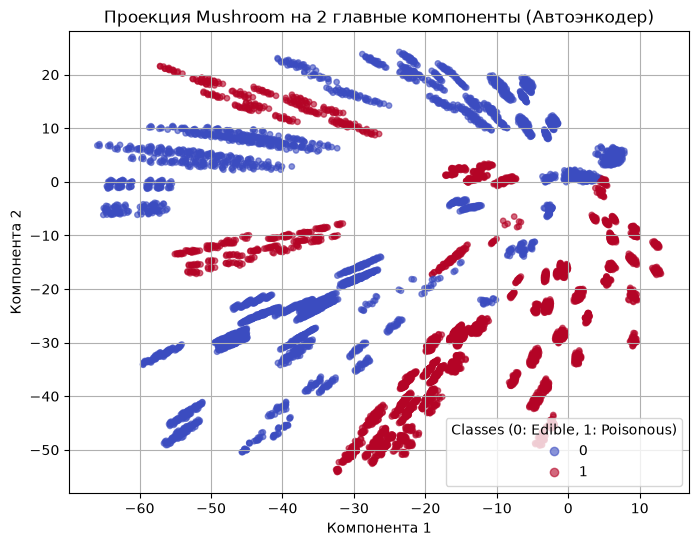

In [12]:
tf.random.set_seed(42)

ae_2d = AutoEncoder(input_dim=input_dim, latent_dim=2)
ae_2d.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

print("Обучение 2D автоэнкодера...")
ae_2d.fit(
    X, X, 
    validation_split=0.2,
    epochs=300, 
    batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# Извлечение 2D проекции
X_2d = ae_2d.encoder.predict(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=15)
plt.title('Проекция Mushroom на 2 главные компоненты (Автоэнкодер)')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')
plt.legend(*scatter.legend_elements(), title="Classes (0: Edible, 1: Poisonous)")
plt.grid(True)
plt.show()

Обучение 3D автоэнкодера...
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step


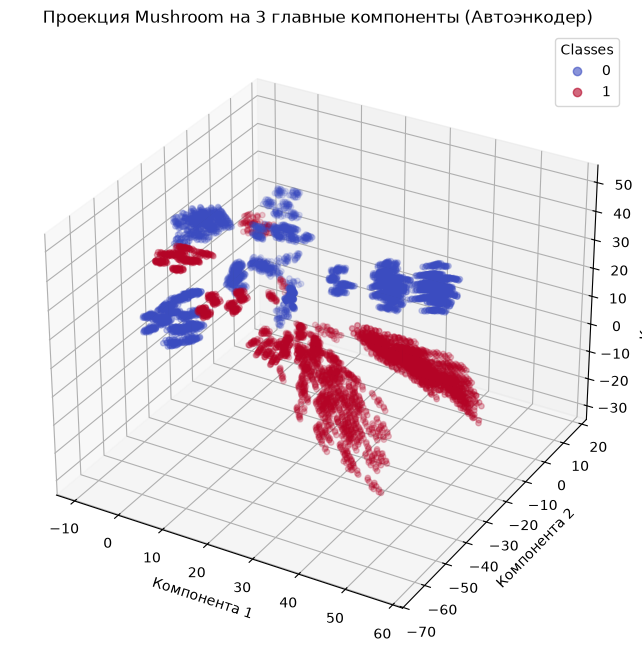

In [13]:
tf.random.set_seed(42)

ae_3d = AutoEncoder(input_dim=input_dim, latent_dim=3)
ae_3d.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy'
)

print("Обучение 3D автоэнкодера...")
ae_3d.fit(
    X, X, 
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0 
)

# Извлечение 3D проекции
X_3d = ae_3d.encoder.predict(X)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='coolwarm', alpha=0.6, s=15)

ax.set_title('Проекция Mushroom на 3 главные компоненты (Автоэнкодер)')
ax.set_xlabel('Компонента 1')
ax.set_ylabel('Компонента 2')
ax.set_zlabel('Компонента 3')
ax.legend(*scatter.legend_elements(), title="Classes")
plt.show()

Вычисление t-SNE 2D...
Вычисление t-SNE 3D...
Вычисление PCA 2D...
Вычисление PCA 3D...


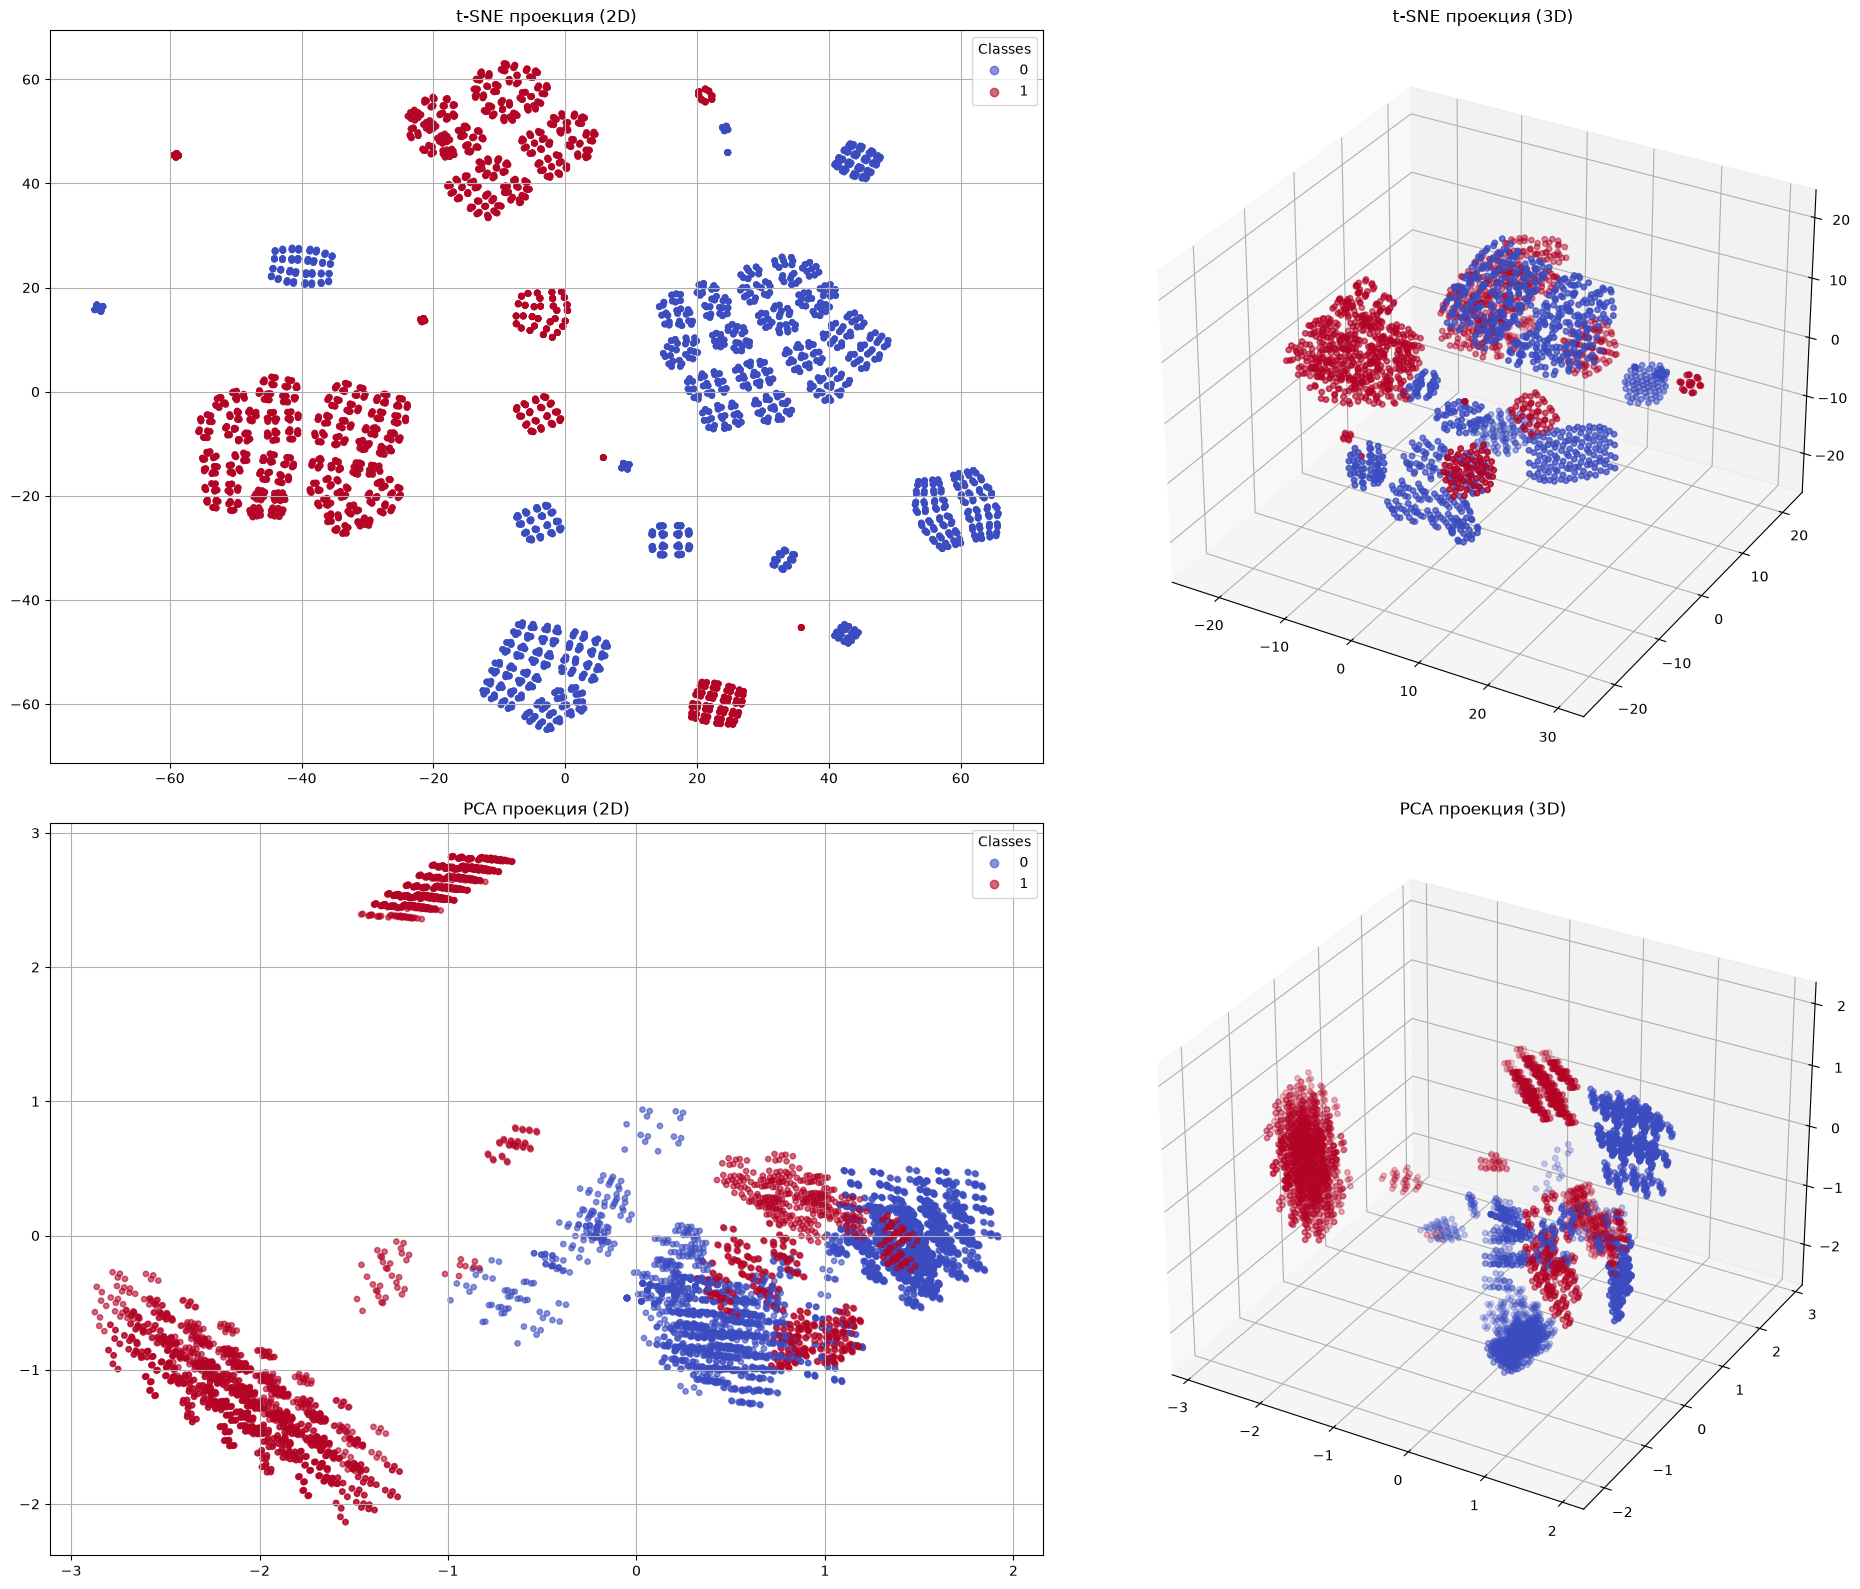

In [15]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Вычисление t-SNE 2D...")
tsne_2d = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne_2d = tsne_2d.fit_transform(X)

print("Вычисление t-SNE 3D...")
tsne_3d = TSNE(n_components=3, random_state=42, n_jobs=-1)
X_tsne_3d = tsne_3d.fit_transform(X)

print("Вычисление PCA 2D...")
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)

print("Вычисление PCA 3D...")
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)


fig = plt.figure(figsize=(20, 16))

# 1. График t-SNE 2D
ax1 = fig.add_subplot(221)
scatter1 = ax1.scatter(X_tsne_2d[:, 0], X_tsne_2d[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=15)
ax1.set_title('t-SNE проекция (2D)')
ax1.legend(*scatter1.legend_elements(), title="Classes")
ax1.grid(True)

# 2. График t-SNE 3D
ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=y, cmap='coolwarm', alpha=0.6, s=15)
ax2.set_title('t-SNE проекция (3D)')

# 3. График PCA 2D
ax3 = fig.add_subplot(223)
scatter3 = ax3.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='coolwarm', alpha=0.6, s=15)
ax3.set_title('PCA проекция (2D)')
ax3.legend(*scatter3.legend_elements(), title="Classes")
ax3.grid(True)

# 4. График PCA 3D
ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='coolwarm', alpha=0.6, s=15)
ax4.set_title('PCA проекция (3D)')

plt.tight_layout()
plt.show()